### Libraries and functions importation

In [32]:
import sys
sys.path.append("../src")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm
import catboost


from preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from data_splitting import train_val_split
from plots import eda_visualizacion_suvs

In [33]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### EDA

**Preprocessing**

In [3]:
data = pd.read_csv('../data/pf_suvs.csv')

In [4]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
       Unnamed: 0       Marca         Modelo     Año  \
5765         5765  Volkswagen           Taos  2025.0   
2678         2678      Toyota  Corolla Cross  2024.0   
15342       15342         BMW             X1  2012.0   
12636       12636        Jeep        Compass  2007.0   
77             77  Volkswagen           Taos  2025.0   

                              Versión   Color Tipo de combustible  Puertas  \
5765     1.4 250 Tsi Highline Bi Tono   Beige               Nafta      5.0   
2678                      2.0 Seg Cvt  Blanco               Nafta      5.0   
15342  2.0 Xdrive 20d Executive 177cv  Blanco              Diésel      5.0   
12636                    2.4 Sport At    Gris               Nafta      5.0   
77               1.4 250 Tsi Highline    Gris               Nafta      5.0   

      Transmisión Motor Tipo de carrocería Con cámara de retroceso Kilómetros  \
5765   Automática   1.4                SUV                     NaN        0.0   
2678   Autom

In [5]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [6]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

- solo hacer limpieza de columnas de suvs 
- pasar de de pesoss a dolar y la borramos  
- col 0 km y usados , 0  1 
- eliminamos lass filas 0 de motor 
- ponemos en puertas todo 5
- pasar con one hot a trsmision 
- borramos unnamed 
- DESCRIPCION -> CLASIFICAR
- TITULO -> BORRAR (es la concatenacion de otros features)

DESPUES DEL SPLIT
- moda de color 
- moda de camara 
- ONE HOT TIPO VENDEDOR 

### *Justificaciones*

In [26]:
print(data[data['Marca'] == 'Volkswagen']['Motor'].dropna().unique().tolist())

['2.0 L 230 CV  350 TSI', '1.4', '1', '1.6', '1.0', 'TURBOALIMENTADO', '2.0', '3.6', '2.0 TDI 140CV', '2', '2.0 TURBO', '3.0', '1.0 tsi', '1.0 200 TSI', '2.0 350TSI', '4.2', '1.0 3 CILINDROS', '1.6 MSI Nafta', '1.4tsi', 'INYECCION MULTI PUNTO', 'TURBO DIESEL INYECCION', '1,6', '1.4 150 CV', '250Tsi', '1.0 116 CV 200 TSI', '1.0 200tsi', '1.0 116cv 200TSI', '350 TSI', '3.0 V6', '1.4  250 TSI 150 CV', '1.4 tsi 200', '1.0 turbo', '1.4 TSI turbo 150 CV', '1.4 tsi', '2.0L 350TSI', '1.4 TSI', '1.4 150 CV  250 TSI', '1.0 170 TSI 101CV MT', '1.0 170 tsi 101cv aut', '1.0 TSI', 'VW 1.4 TSI 150cv', '1.4 150 CV 250 TSI', '1.0 T', '1.4t', '250TSI 150cv']


In [34]:
print(data['Marca'].dropna().unique().tolist())

['Ford', 'Volkswagen', 'Jeep', 'BAIC', 'Kia', 'Hyundai', 'Porsche', 'Peugeot', 'Fiat', 'Chevrolet', 'Citroën', 'BMW', 'Audi', 'Honda', 'Nissan', 'Mercedes-Benz', 'Renault', 'Suzuki', 'Toyota', 'D.S.', 'Chery', 'Daihatsu', 'SsangYong', 'Dodge', 'JAC', 'Land Rover', 'Alfa Romeo', 'Haval', 'Volvo', 'Lifan', 'Mini', 'D·S', 'Mitsubishi', 'Range Rover', 'Hiunday', 'Jetour', 'GWM', 'KAIYI', 'Lexus', 'Isuzu', 'Rrenault', 'Subaru', 'Jetur', 'DS AUTOMOBILES', 'hiunday', 'Jaguar', 'Vol']


In [18]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

─── Muestra #0 (índice 17) ───
  Descripción: Buscás, encontrás. Tenés, vendés. Todo en un mismo lugar. Bienvenido a Mamba Cars, donde innovamos una nueva experiencia en la compra y venta de vehiculos en Mar del Plata.Vení a vivir la experiencia Mamba, donde vas encontrar la llave que buscabas para poner en marcha tu próximo viaje
  Palabras positivas encontradas: ninguna
  Palabras negativas encontradas: ninguna

─── Muestra #1 (índice 87) ───
  Descripción: Audi Q5 Quattro 2.0 Turbo 2011 Full con 6ta, Llantas, 4 Levanta Vidrios, Climatizador, Cierre Central, Aire, Dirección, etc. Bienvenidos a Automotores España, líder en servicio y atención al cliente.Venta, permuta y consignación de autos 0 km y usados.Fundada en 1973, nuestra agencia lleva más de 40 años de experiencia en el mercado automotor. Desde la ciudad de Chivilcoy, somos líderes en el mercado local y reconocidos en toda la provincia de Buenos Aires. Contamos además con clientes en todo el país.Con un showroom de 900 mts2, 

**NUEVO DATASET**

In [8]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
         Marca          Modelo     Año                    Versión  Color  \
3315      Jeep         Patriot  2013.0    2.0 Sport 4x2 156cv Mtx  Negro   
17265     Ford        Ecosport  2011.0              1,6 L 4x2 XLS  Negro   
12180  Citroën     C5 Aircross  2021.0     1.6 Thp Eat6 Feel Pack   Gris   
12182      Kia            Soul  2016.0           1.6 Ex 132cv 6at  Negro   
15325     Jeep  Grand Cherokee  2006.0  3.0 Crd Laredo Automática   Gris   

      Tipo de combustible  Puertas Transmisión Motor Con cámara de retroceso  \
3315                Nafta      5.0      Manual   2.0                     NaN   
17265               Nafta      5.0      Manual   1.6                     NaN   
12180               Nafta      5.0  Automática   1.6                     NaN   
12182               Nafta      5.0  Automática   1.6                      Sí   
15325              Diésel      5.0  Automática   3.0                     NaN   

       Kilómetros                  

In [9]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Marca,str,0,46
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2054
Color,str,389,69
Tipo de combustible,str,0,8
Puertas,float64,0,4
Transmisión,str,11,4
Motor,str,0,271
Con cámara de retroceso,str,13548,2


**VISUALIZACION DEL EDA HASTA AHORA**

Distribuciones individuales


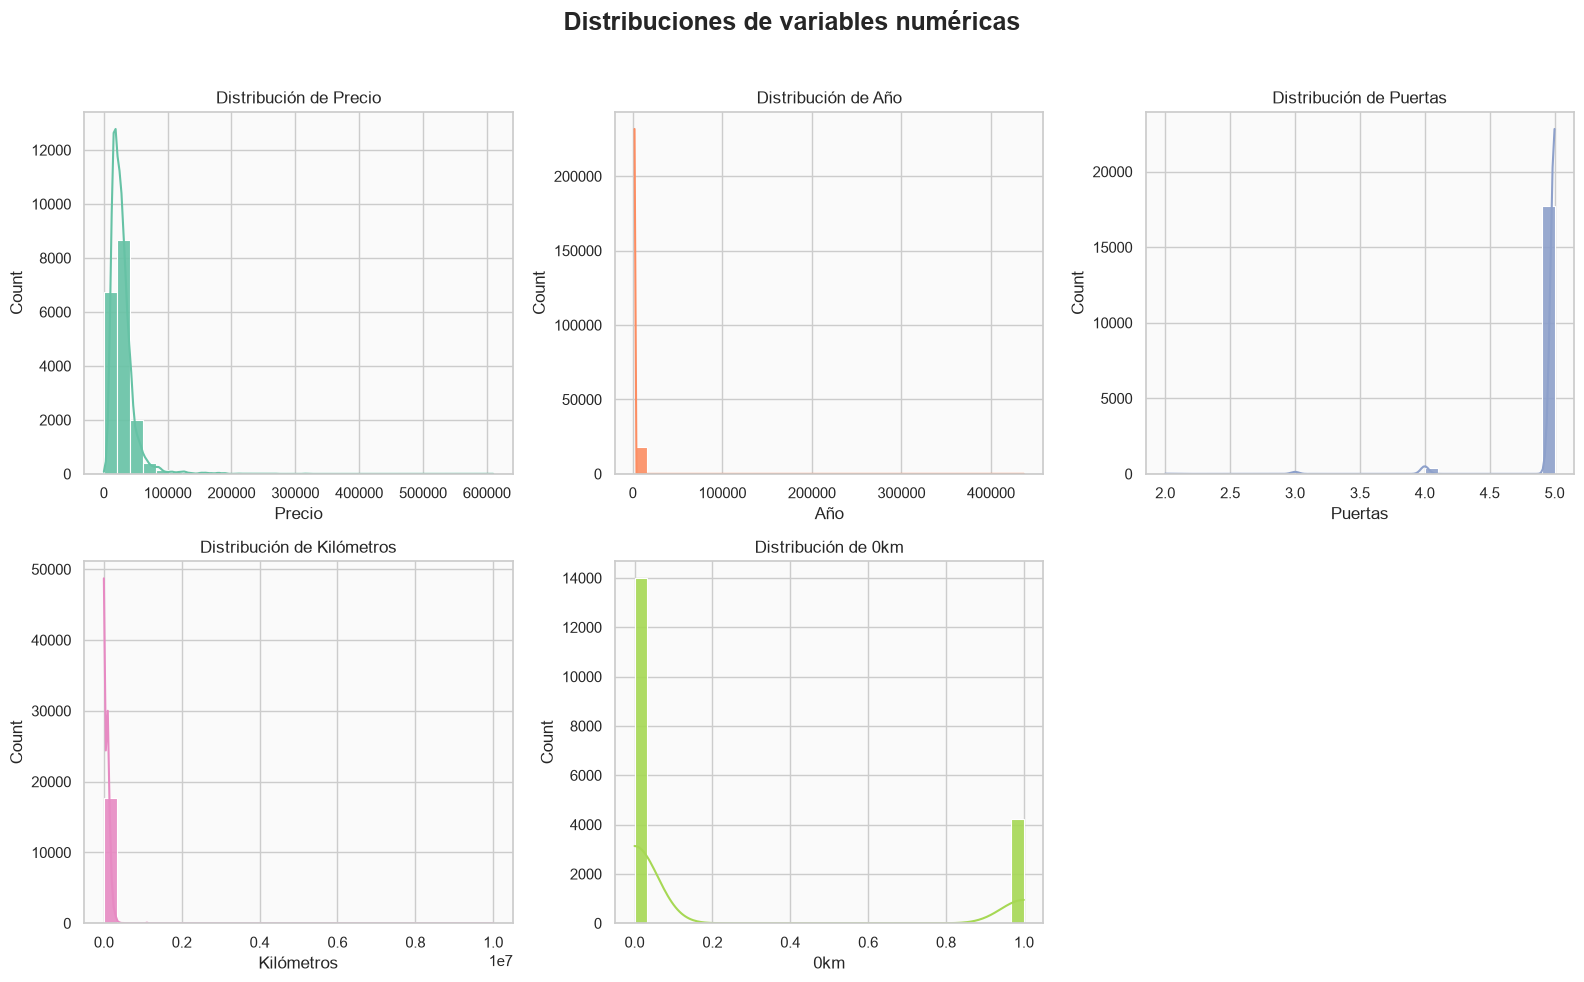

Boxplots individuales


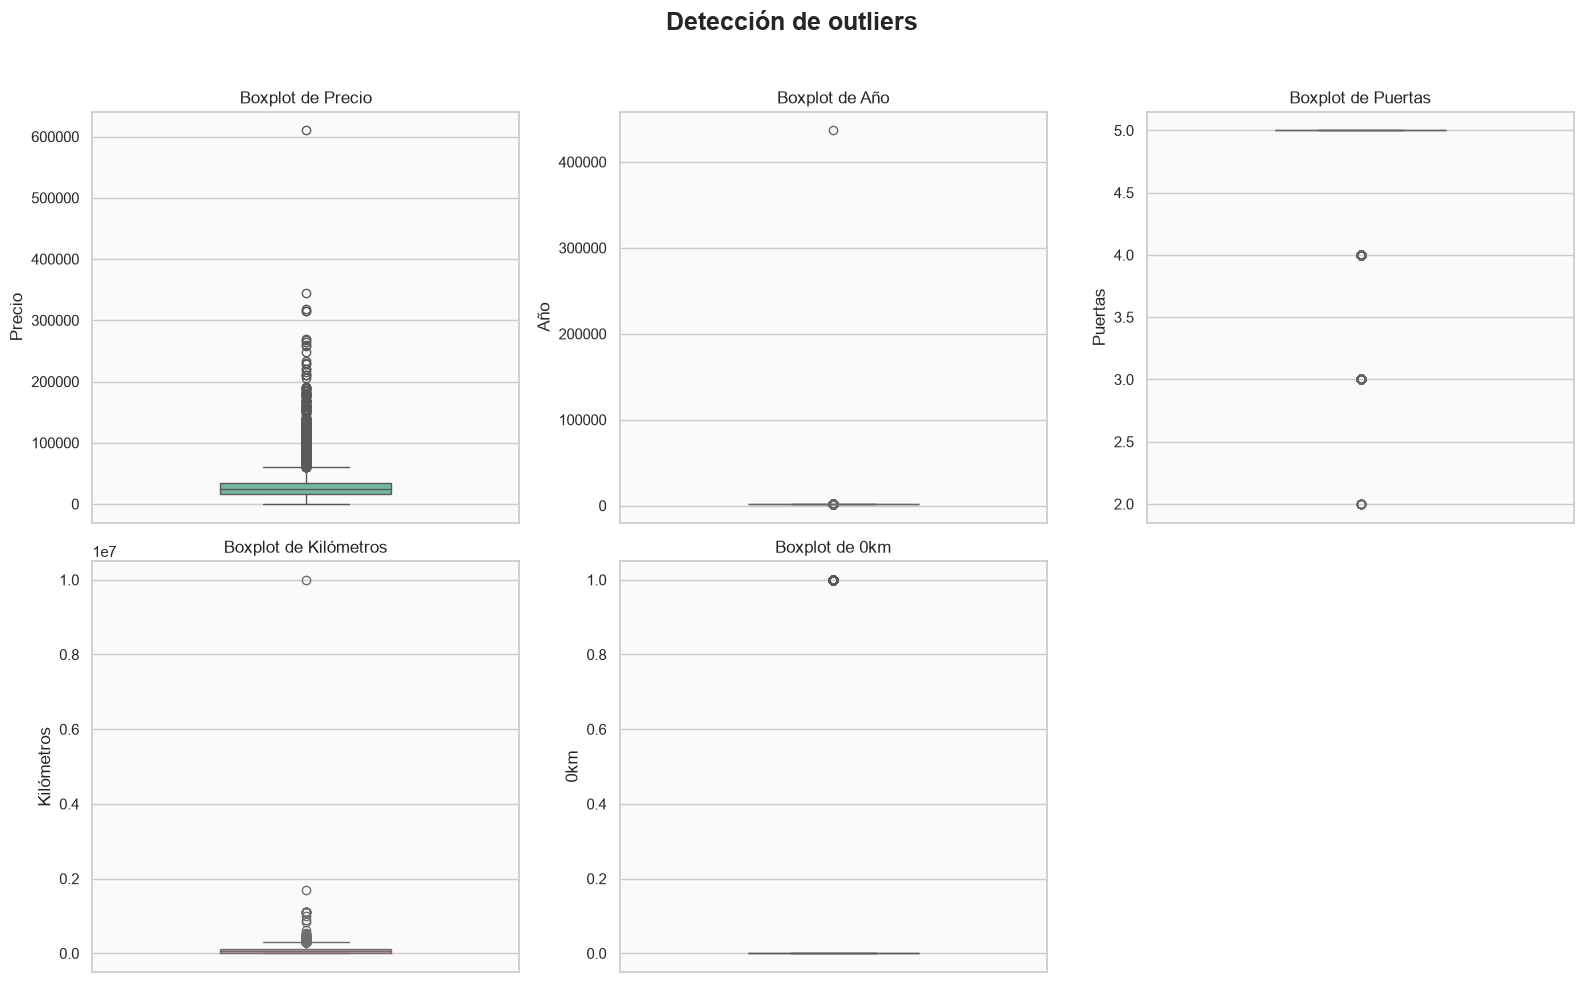

Relación con el precio


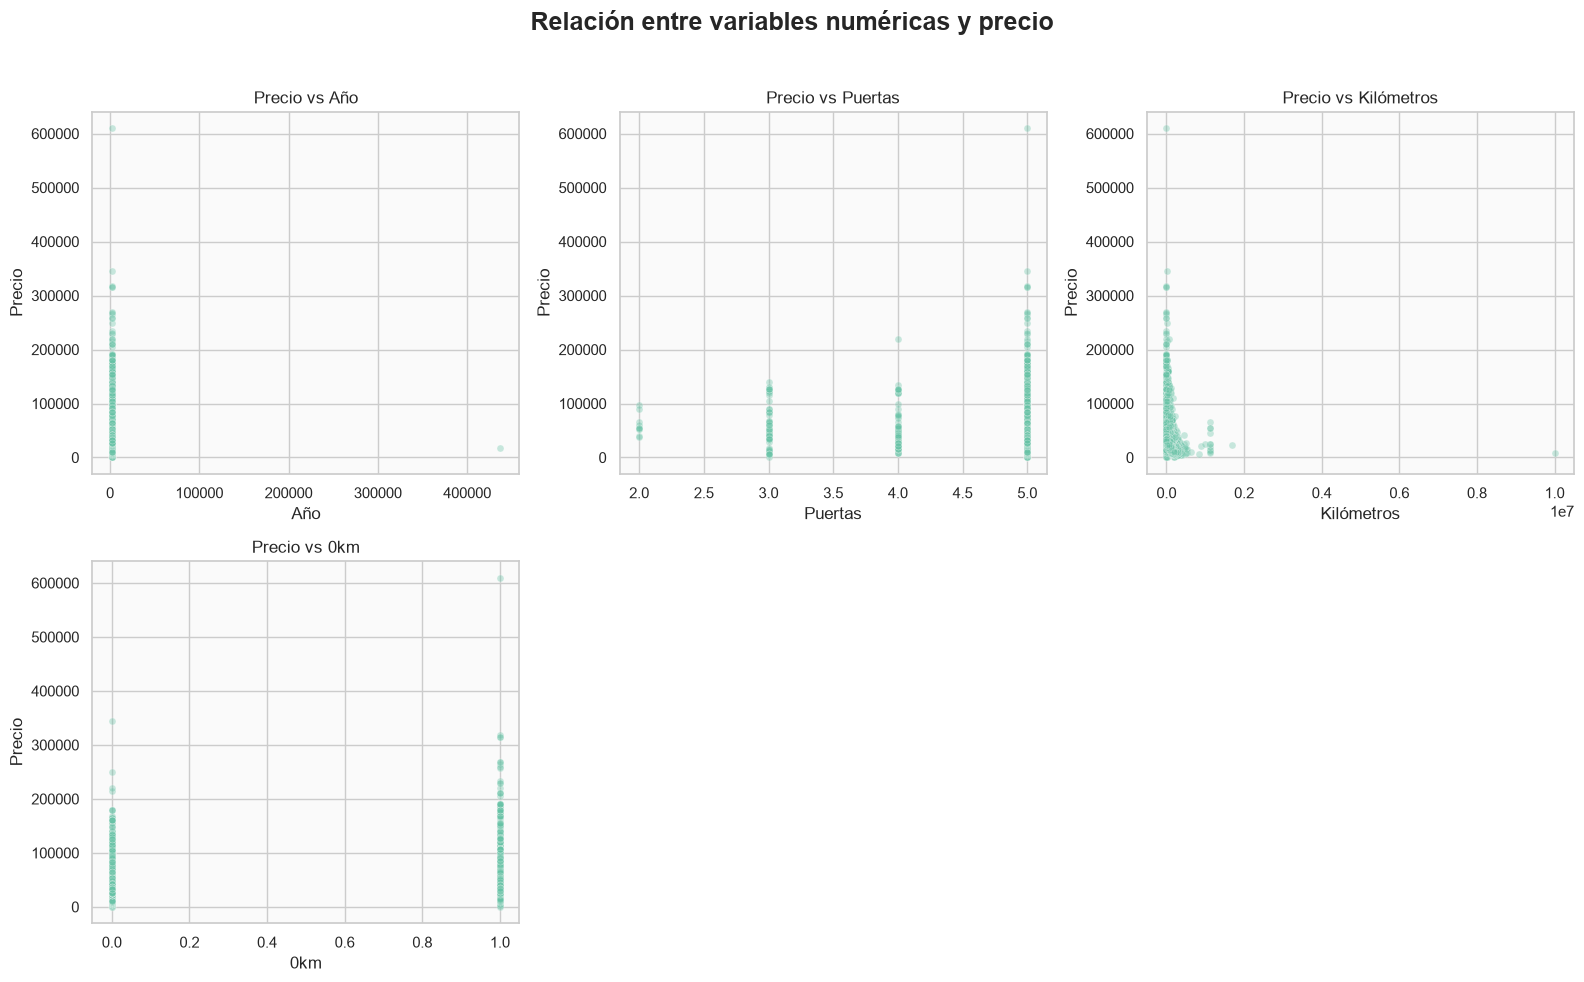

Relación de variables categóricas con el precio


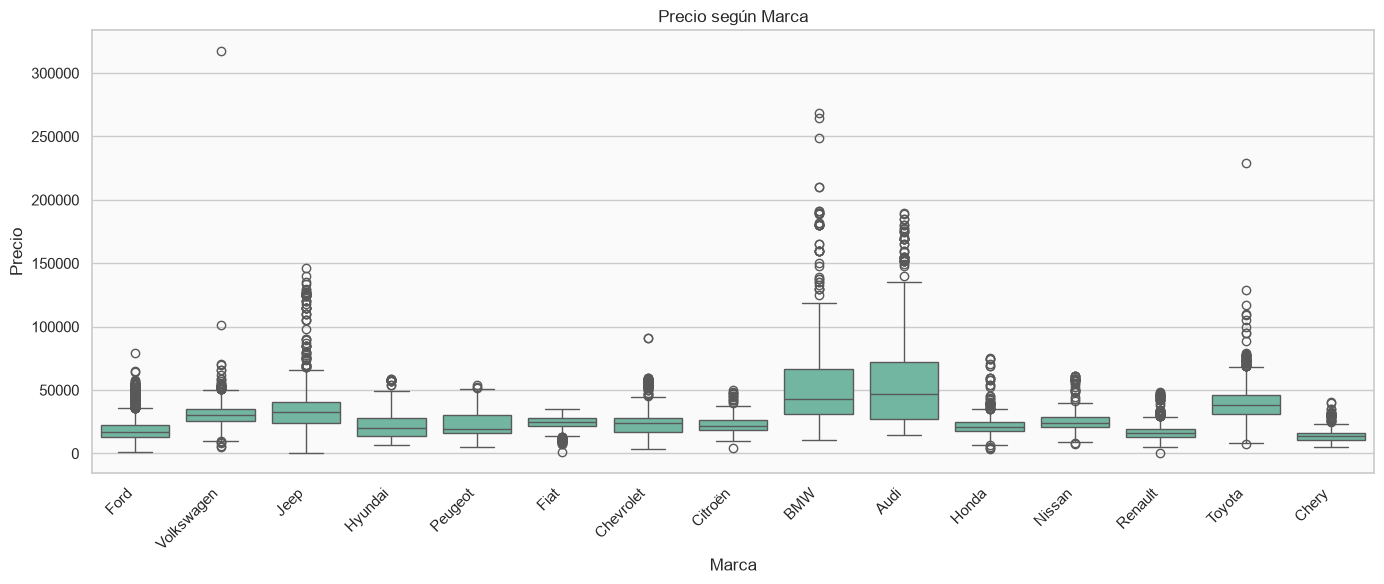

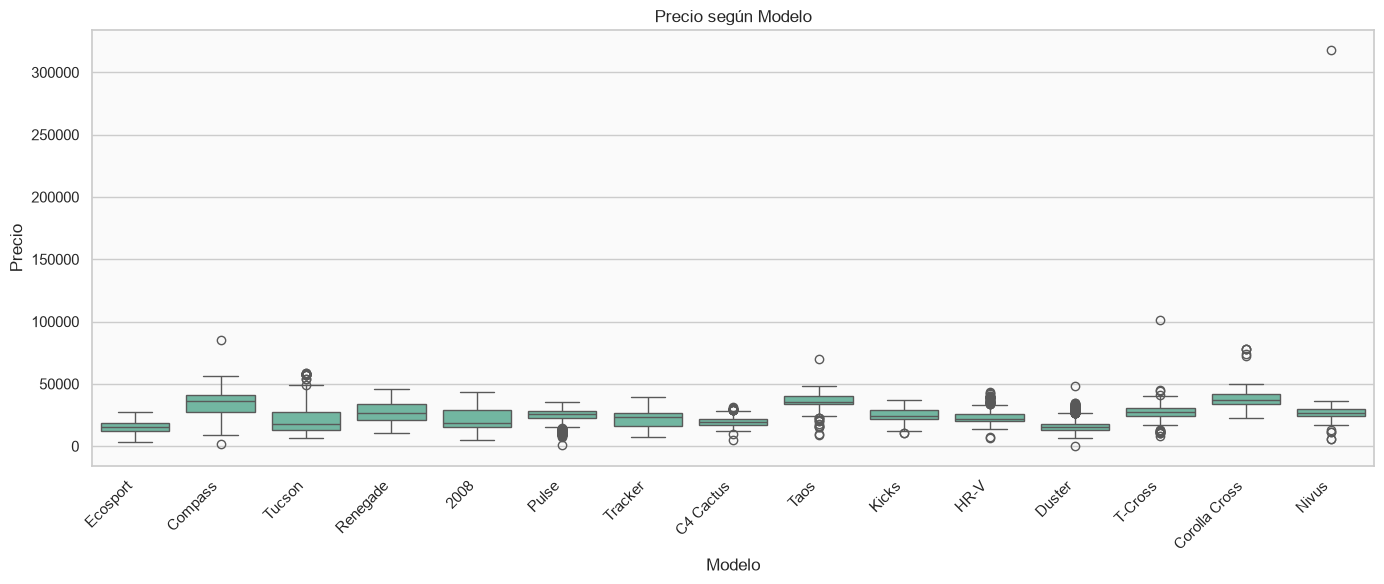

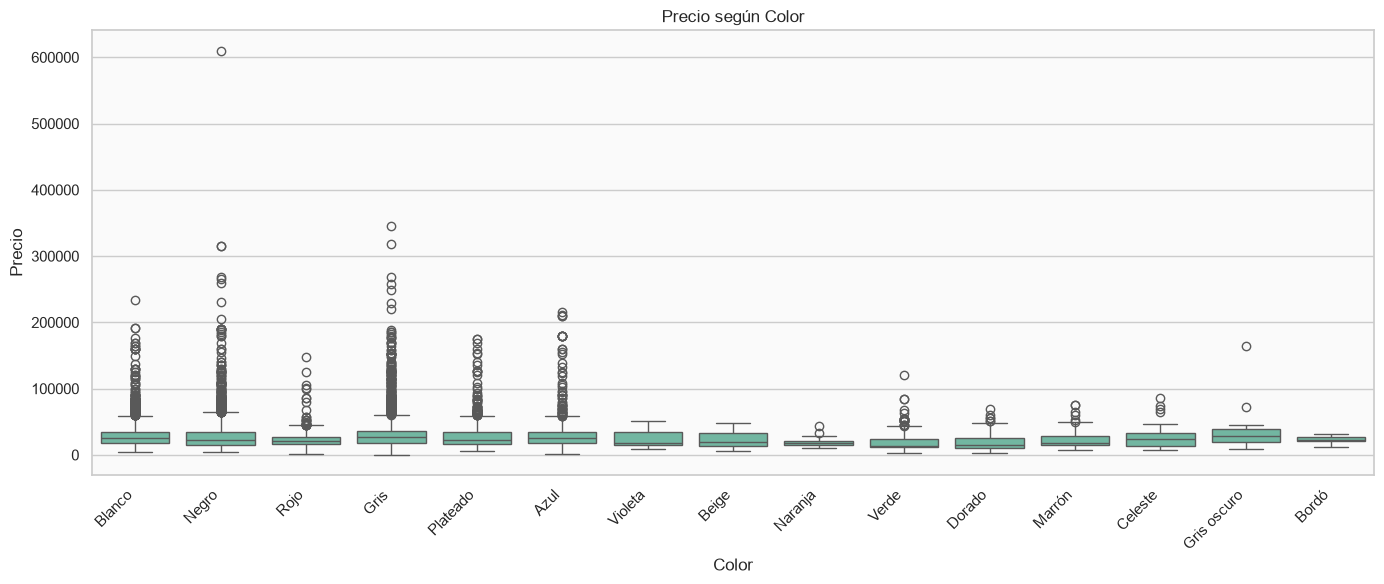

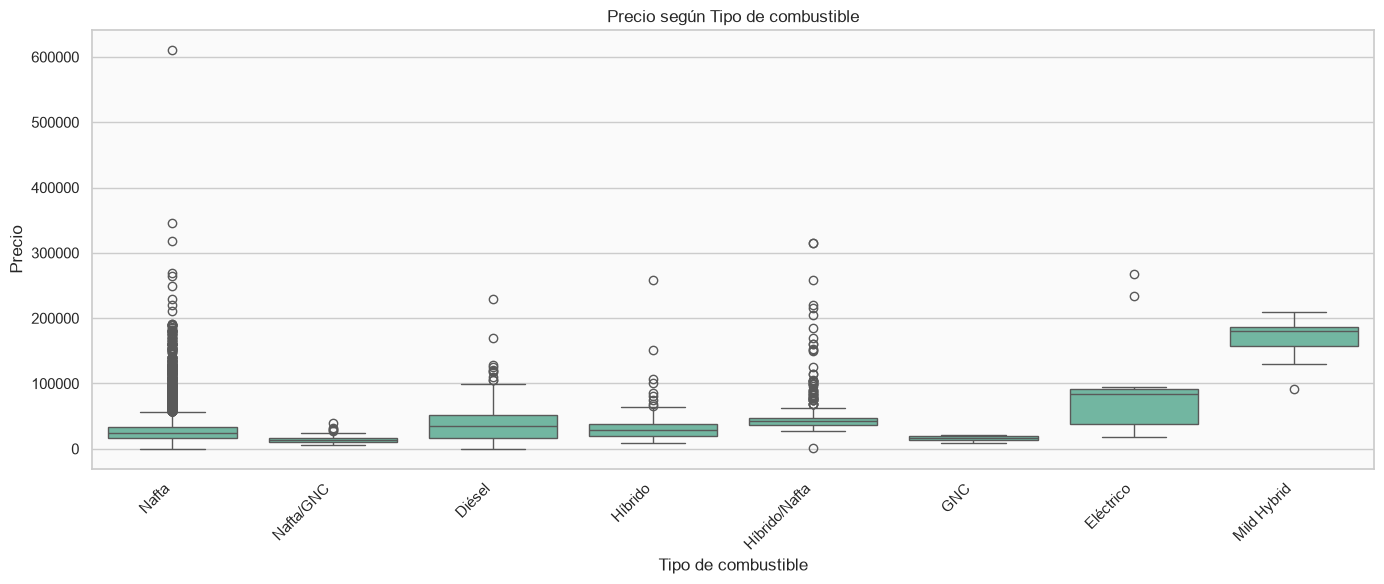

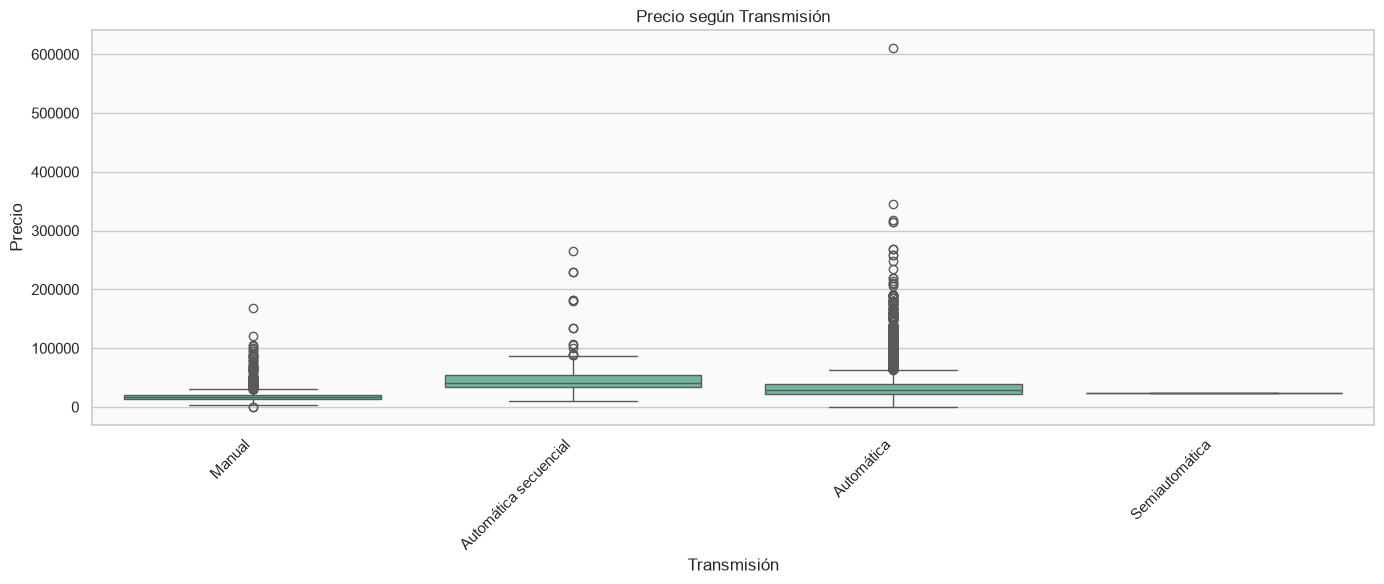

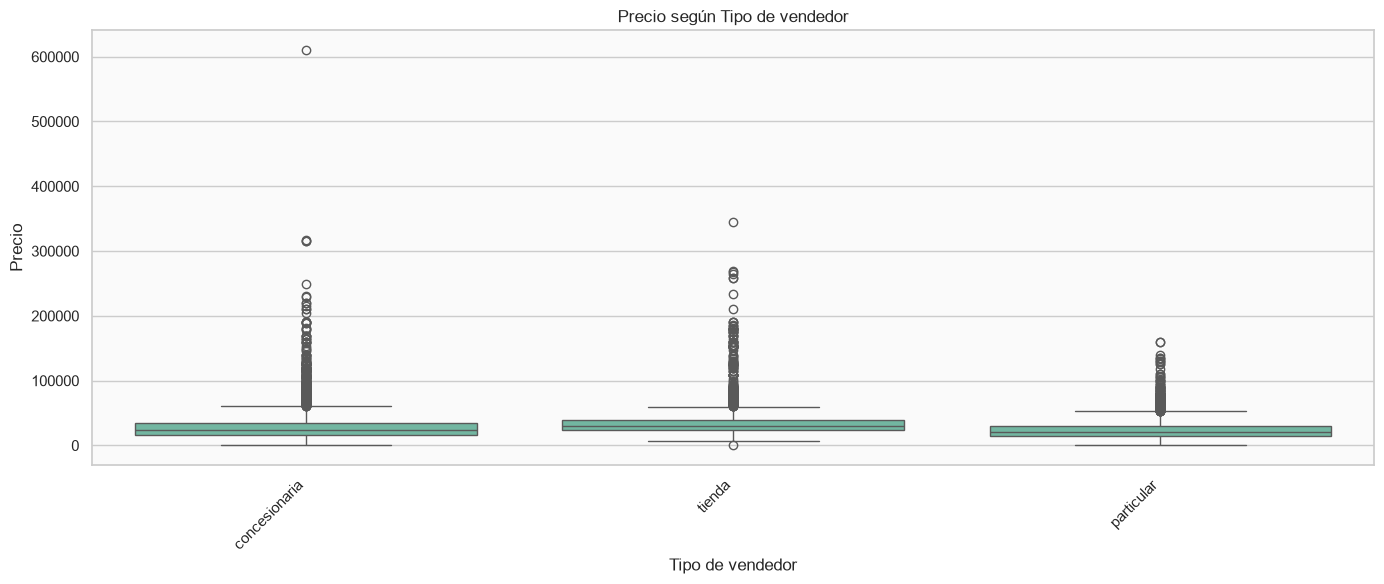

Matriz de correlación


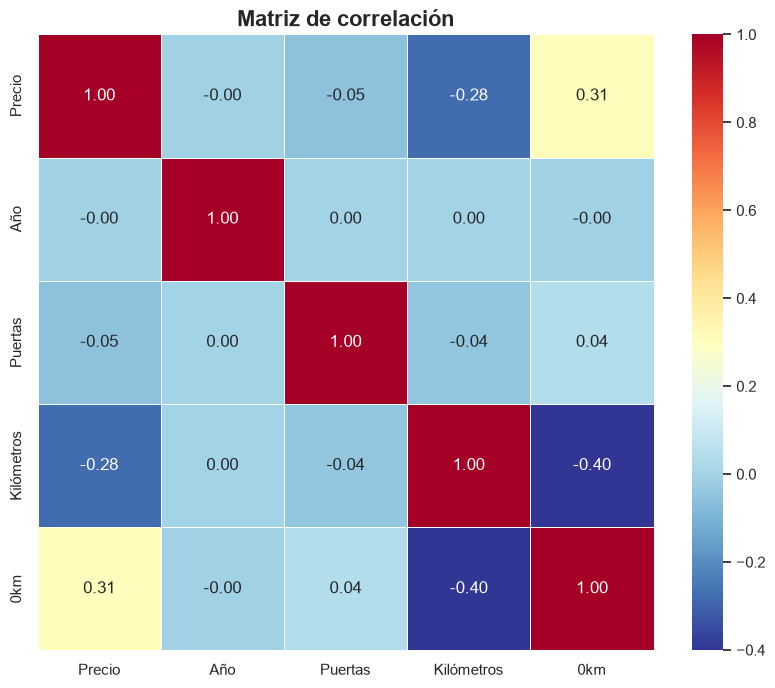

In [10]:
#Plots
eda_visualizacion_suvs(data_pre, target= "Precio", show_pairplot= False)

Para terminar con el ***preprocesamiento de datos***, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara"  evitando el data leakage.

In [11]:
train, val = train_val_split(data_pre)

Tamaño conjunto de entrenamiento -> (14572, 16), 
Tamaño conjunto de validación -> (3644, 16)


In [12]:
#Preprocessing post split using the train parameters
train, val = preprocesamiento_post_split(train, val)

In [ ]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ['Marca', 'Color', 'Modelo', 'Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
train, val = onehot_encoding(train, val, columnas_oh)

In [14]:
print('Final del preprocesamiento sobre Entrenamiento')
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "nulos": train.isnull().sum(),
    "unicos": train.nunique()
})
summary

Final del preprocesamiento sobre Entrenamiento


,dtype,nulos,unicos
Marca,str,0,43
Modelo,str,0,137
Año,float64,0,39
Versión,str,0,1853
Color,str,0,63
Puertas,float64,0,4
Motor,str,0,237
Kilómetros,float64,0,1849
Título,str,0,1976
Precio,float64,0,2522


In [15]:
print('Final del preprocesamiento sobre Validación')
summary = pd.DataFrame({
    "dtype": val.dtypes,
    "nulos": val.isnull().sum(),
    "unicos": val.nunique()
})
summary

Final del preprocesamiento sobre Validación


,dtype,nulos,unicos
Marca,str,0,39
Modelo,str,0,123
Año,float64,0,35
Versión,str,0,907
Color,str,0,33
Puertas,float64,0,4
Motor,str,0,105
Kilómetros,float64,0,750
Título,str,0,930
Precio,float64,0,1165


### MODELOS

### Comparison bewtween models

### Final Model